# Battery size optimization — continuous MILP sweep

Perfect-foresight (MILP) cost of one household over a full year, solved once per battery
capacity from **0 to 100 kWh**. Every solve uses the *continuous* formulation
(`use_discrete_actions=False`), i.e. the battery setpoint is a free variable, so each point on
the curve is the theoretical optimum for that capacity — no policy can do better.

**Tariff: GEN-I Dinamični.** The household has a PV self-supply device, so the applicable
GEN-I dynamic price list is *GEN-I Dinamični – Samooskrba* (`GENI_SAMO_DINAMICNI`,
`pricing_scheme="si_samooskrba"`): import at SIPX + 0.01199 EUR/kWh plus network charges,
contributions and VAT; export credited at SIPX − 0.01199 EUR/kWh. The non-self-supply
list (`GENI_DINAMICNI`, `si_dobava`) is deliberately *not* used here — that scheme has no
export-netting logic and credits every exported kWh at the full retail rate including network
charges and VAT, which makes grid arbitrage unboundedly profitable and leaves the sizing
curve without a finite optimum.

**How the year is solved.** One MILP per capacity over the whole 35 136-step year — the same
single `run_milp_benchmark` call `Household_local model.ipynb` makes, just over the full
dataset instead of the test third, and with `peak_reset_months` left at the repository default
(the ratchet peak never resets, one annual peak charge). Solved to a 0.1 % MIP gap
(`gapRel`): at proven optimality CBC needs 5–20 min on some capacities, at 0.1 % it needs
25–150 s, and 0.1 % of the annual bill is far below the ~20 EUR spacing between adjacent
points on the curve.

**Fair comparison across sizes.** Every solve starts at half capacity — the environment's own
reset SOC — and is *required to end there too* (`final_soc_kwh = initial_soc_kwh`). Without
the terminal floor the solver empties the battery into the last intervals of the horizon, so
each larger battery would book the sell-off of its own bigger opening charge as a saving.

In [1]:
### Imports
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import pulp
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

import importlib
import Data_Loader as dl
import Environment as environment_module
import MILP_Benchmark as milp_module

dl = importlib.reload(dl)
environment_module = importlib.reload(environment_module)
milp_module = importlib.reload(milp_module)

HouseholdEnvironment = environment_module.HouseholdEnvironment
run_milp_benchmark = milp_module.run_milp_benchmark

print("Imports ready.")

Imports ready.


## 1. Configuration

Everything the study depends on lives in this one cell.

In [2]:
### Household / dataset -----------------------------------------------------
HOUSEHOLD_ID = 29
DATASET_NAME = "Fluvius_PV"        # PV household -> GEN-I samooskrba dynamic list
SMP_COUNTRY_ID = "Slovenia"

PRICE_COLUMN = "SMP"
GENERATION_COLUMN = "Feed_In_Volume_kWh"
CONSUMPTION_COLUMN = "Consumption_Volume_kWh"

### Tariff ------------------------------------------------------------------
PRICING_SCHEME = "si_samooskrba"
PAKET_ID = "GENI_SAMO_REDNI"   # GEN-I Dinamični – Samooskrba
PRICING_REFERENCE_YEAR = 2026      # dataset is 2024; SI tariff regime to price under
PEAK_RESET_MONTHS = None           # repository default: ratchet peak never resets

### Battery -----------------------------------------------------------------
BATTERY_SIZES_KWH = np.unique(np.concatenate([
    np.arange(0.0, 11.0, 1.0),     # fine where the curve bends
    np.arange(12.5, 30.0, 2.5),
    np.arange(30.0, 101.0, 10.0),
]))

CHARGE_EFFICIENCY = 0.95
DISCHARGE_EFFICIENCY = 0.95

# Power rating scales with capacity (a 5 kWh pack does not get a 10 kW inverter),
# capped at a typical residential connection/inverter limit.
C_RATE = 0.5                       # kW per kWh of capacity
INVERTER_MAX_KW = 11.0

SOC_FRACTION = 0.5                 # start AND end each solve at this share of capacity

### Solver ------------------------------------------------------------------
SOLVER_GAP_REL = 0.001             # 0.1 % MIP gap — proven optimality costs 10-20x the time
SOLVER_TIME_LIMIT_S = 900

### Economics (assumptions — change freely, the plots follow) ----------------
CAPEX_SCENARIOS_EUR_PER_KWH = [150.0, 250.0, 350.0]
BATTERY_LIFETIME_YEARS = 12
DISCOUNT_RATE = 0.05

print(f"{len(BATTERY_SIZES_KWH)} battery sizes: {BATTERY_SIZES_KWH}")

26 battery sizes: [  0.    1.    2.    3.    4.    5.    6.    7.    8.    9.   10.   12.5
  15.   17.5  20.   22.5  25.   27.5  30.   40.   50.   60.   70.   80.
  90.  100. ]


## 2. Load the household and the SMP price series

Same pipeline as `Household_local model.ipynb`: household profile from `Input data`, SMP
overwritten with the selected country's series, auto-detecting EUR/MWh inputs.

In [3]:
input_data = dl.load_household_data(HOUSEHOLD_ID, dataset=DATASET_NAME)

smp_country = dl.load_smp_data(SMP_COUNTRY_ID)
smp_aligned = smp_country.reindex(input_data.index, method="ffill")
smp_series = pd.to_numeric(smp_aligned[PRICE_COLUMN], errors="coerce").ffill().bfill()

# Auto-detect legacy EUR/MWh inputs and convert to EUR/kWh.
smp_scale = 1000.0 if float(smp_series.abs().quantile(0.95)) > 2.0 else 1.0
input_data[PRICE_COLUMN] = (smp_series / smp_scale).astype(float)

step_minutes = float(
    input_data.index.to_series().sort_values().diff().dropna().dt.total_seconds().median() / 60.0
)
STEPS_PER_DAY = int(round(1440.0 / step_minutes))
HOURS_PER_STEP = 24.0 / STEPS_PER_DAY

period_days = (input_data.index[-1] - input_data.index[0]).total_seconds() / 86400.0
ANNUALIZE = 365.0 / period_days

annual_consumption_kwh = float(input_data[CONSUMPTION_COLUMN].sum()) * ANNUALIZE
annual_generation_kwh = float(input_data[GENERATION_COLUMN].sum()) * ANNUALIZE

print(f"Household {HOUSEHOLD_ID} ({DATASET_NAME}): {len(input_data)} intervals of "
      f"{step_minutes:.0f} min, {input_data.index[0]:%Y-%m-%d} -> {input_data.index[-1]:%Y-%m-%d} "
      f"({period_days:.1f} days)")
print(f"Consumption {annual_consumption_kwh:,.0f} kWh/a | PV feed-in "
      f"{annual_generation_kwh:,.0f} kWh/a | SMP {input_data[PRICE_COLUMN].min():.3f} .. "
      f"{input_data[PRICE_COLUMN].max():.3f} EUR/kWh (median "
      f"{input_data[PRICE_COLUMN].median():.3f})")
if annual_generation_kwh <= 0:
    print("WARNING: no PV in this profile — pricing_scheme='si_samooskrba' has nothing to net.")

Household 29 (Fluvius_PV): 35136 intervals of 15 min, 2024-01-01 -> 2024-12-31 (366.0 days)
Consumption 1,906 kWh/a | PV feed-in 1,268 kWh/a | SMP -0.106 .. 1.022 EUR/kWh (median 0.086)


## 3. Environment + chained monthly MILP

`build_env(capacity_kwh)` returns the environment the MILP reads its battery and tariff
parameters off. `solve_year(env)` is a single `run_milp_benchmark` call over the whole year in
the continuous formulation, pinned to start and finish at `SOC_FRACTION` of capacity.

In [4]:
def build_env(capacity_kwh, dataset=None):
    '''Environment for one battery capacity. Power rating scales with capacity.'''
    dataset = input_data if dataset is None else dataset
    power_kw = min(C_RATE * float(capacity_kwh), INVERTER_MAX_KW)
    step_kwh = power_kw * HOURS_PER_STEP
    return HouseholdEnvironment(
        dataset=dataset,
        price_column=PRICE_COLUMN,
        generation_column=GENERATION_COLUMN,
        consumption_column=CONSUMPTION_COLUMN,
        action_mode="continuous",
        allow_curtailment=True,
        reset_mode="deterministic",
        episode_length=len(dataset) - 1,
        steps_per_day=STEPS_PER_DAY,
        battery_capacity_kwh=float(capacity_kwh),
        charge_efficiency=CHARGE_EFFICIENCY,
        discharge_efficiency=DISCHARGE_EFFICIENCY,
        max_charge_kwh=step_kwh,
        max_discharge_kwh=step_kwh,
        pricing_scheme=PRICING_SCHEME,
        pricing_reference_year=PRICING_REFERENCE_YEAR,
        pricing_options={"paket_id": PAKET_ID},
        peak_reset_months=PEAK_RESET_MONTHS,
    )


SOLVER = pulp.PULP_CBC_CMD(msg=False, gapRel=SOLVER_GAP_REL, timeLimit=SOLVER_TIME_LIMIT_S)


def solve_year(env):
    '''One continuous MILP over the whole horizon. Starts and ends at
    SOC_FRACTION of capacity, so no capacity gets free energy at t=0.'''
    soc_kwh = SOC_FRACTION * env.battery_capacity_kwh
    return run_milp_benchmark(
        env,
        use_discrete_actions=False,      # continuous battery setpoint
        initial_soc_kwh=soc_kwh,
        final_soc_kwh=soc_kwh,
        solver=SOLVER,
        verbose=False,
    )


def summarize(df, capacity_kwh, env):
    '''Per-capacity metrics extracted from a solved trajectory.'''
    net_grid_kwh = (
        df["Consumption"] + df["Charge_kW"] + df["Spill_kW"]
        - df["Generation"] - df["Discharge_kW"]
    )
    pv_surplus = np.maximum(df["Generation"] - df["Consumption"], 0.0)
    grid_charged = np.maximum(df["Charge_kW"] - pv_surplus, 0.0)
    return {
        "Capacity_kWh": float(capacity_kwh),
        "Power_kW": min(C_RATE * float(capacity_kwh), INVERTER_MAX_KW),
        "Cost_EUR": float(df["Cum_Cost"].iloc[-1]) * ANNUALIZE,
        "Charged_kWh": float(df["Charge_kW"].sum()) * ANNUALIZE,
        "Discharged_kWh": float(df["Discharge_kW"].sum()) * ANNUALIZE,
        "Grid_Charged_kWh": float(grid_charged.sum()) * ANNUALIZE,
        "Import_kWh": float(net_grid_kwh.clip(lower=0).sum()) * ANNUALIZE,
        "Export_kWh": float((-net_grid_kwh).clip(lower=0).sum()) * ANNUALIZE,
        "Curtailed_kWh": float(df["Spill_kW"].sum()) * ANNUALIZE,
        "Peak_Import_kW": float(net_grid_kwh.max()) / HOURS_PER_STEP,
        "Equivalent_Full_Cycles": (
            float(df["Discharge_kW"].sum()) * ANNUALIZE / capacity_kwh if capacity_kwh > 0 else 0.0
        ),
    }


print("Helpers defined.")

Helpers defined.


## 4. Sweep 0 → 100 kWh

One continuous MILP per capacity over the full year. Expect 25–150 s per capacity, ~30 min for the 26-point sweep.

In [5]:
%%time
results = []
trajectories = {}
sweep_start = time.time()

for capacity in BATTERY_SIZES_KWH:
    t0 = time.time()
    env = build_env(capacity)
    df_year = solve_year(env)
    row = summarize(df_year, capacity, env)
    row["Solve_s"] = time.time() - t0
    results.append(row)
    trajectories[float(capacity)] = df_year
    print(f"  {capacity:6.1f} kWh @ {row['Power_kW']:5.2f} kW -> "
          f"{row['Cost_EUR']:9.2f} EUR/a   "
          f"({row['Equivalent_Full_Cycles']:5.1f} full cycles, {row['Solve_s']:5.1f} s)",
          flush=True)

df_sizing = pd.DataFrame(results).sort_values("Capacity_kWh").reset_index(drop=True)
print(f"\nSweep finished in {(time.time() - sweep_start) / 60:.1f} min.")

     0.0 kWh @  0.00 kW ->    422.75 EUR/a   (  0.0 full cycles,   7.7 s)
     1.0 kWh @  0.50 kW ->    412.31 EUR/a   ( 91.3 full cycles,  20.1 s)
     2.0 kWh @  1.00 kW ->    405.96 EUR/a   ( 69.1 full cycles,  20.2 s)
     3.0 kWh @  1.50 kW ->    400.34 EUR/a   ( 59.3 full cycles,  20.3 s)
     4.0 kWh @  2.00 kW ->    395.27 EUR/a   ( 53.1 full cycles,  20.7 s)
     5.0 kWh @  2.50 kW ->    391.86 EUR/a   ( 48.9 full cycles,  20.8 s)
     6.0 kWh @  3.00 kW ->    389.49 EUR/a   ( 45.0 full cycles,  20.5 s)
     7.0 kWh @  3.50 kW ->    387.34 EUR/a   ( 41.9 full cycles,  20.5 s)
     8.0 kWh @  4.00 kW ->    385.68 EUR/a   ( 39.0 full cycles,  20.0 s)
     9.0 kWh @  4.50 kW ->    384.36 EUR/a   ( 36.2 full cycles,  20.8 s)
    10.0 kWh @  5.00 kW ->    383.05 EUR/a   ( 34.0 full cycles,  20.1 s)
    12.5 kWh @  6.25 kW ->    380.06 EUR/a   ( 29.8 full cycles,  29.1 s)
    15.0 kWh @  7.50 kW ->    377.67 EUR/a   ( 26.6 full cycles,  33.4 s)
    17.5 kWh @  8.75 kW ->    375.77 E

## 5. Savings and battery economics

`Savings_EUR` is measured against the 0 kWh solve — the same household, same tariff, same
perfect foresight, no battery.

The battery is paid for once and earns over its service life, so the two sides are put on the
same yearly footing with the **capital recovery factor**

    a = r / (1 - (1 + r)^-n)         r = DISCOUNT_RATE, n = BATTERY_LIFETIME_YEARS

which is the constant yearly payment that repays 1 EUR of capital over `n` years at interest
`r` — the annuity behind any loan schedule. A battery of size `C` at `capex` EUR/kWh therefore
costs `C * capex * a` EUR per year, and

    net annual benefit(C) = savings(C) - C * capex * a

The size that maximizes this is the optimum. Two derived numbers make the assumption easy to
argue with:

* `Break_Even_Capex = savings(C) / (C * a)` — the installed cost at which that size exactly
  breaks even. Compare it against a real quote instead of against `CAPEX_SCENARIOS`.
* `Payback_y = C * capex / savings(C)` — simple (undiscounted) payback. `n = 12 years` is an
  *assumed service life*, not a payback target: it is the usual residential Li-ion warranty
  band (10–15 years, ~6 000 cycles). Any size whose payback lands under it is profitable in
  the discounted sense too. Note the MILP cycles small batteries 300–440 equivalent full
  cycles a year, so for those the 6 000-cycle limit, not the calendar, sets the life —
  shortening `BATTERY_LIFETIME_YEARS` raises `a` and shrinks the optimum.

In [6]:
cost_no_battery = float(df_sizing.loc[df_sizing["Capacity_kWh"] == 0.0, "Cost_EUR"].iloc[0])

annuity_factor = (
    DISCOUNT_RATE / (1 - (1 + DISCOUNT_RATE) ** -BATTERY_LIFETIME_YEARS)
    if DISCOUNT_RATE > 0 else 1.0 / BATTERY_LIFETIME_YEARS
)

df_sizing["Savings_EUR"] = cost_no_battery - df_sizing["Cost_EUR"]

# Marginal value of the next kWh of capacity (EUR per kWh per year).
df_sizing["Marginal_EUR_per_kWh"] = (
    df_sizing["Savings_EUR"].diff() / df_sizing["Capacity_kWh"].diff()
)

# Cost per kWh of capacity at which a battery of this size just breaks even.
df_sizing["Break_Even_Capex"] = np.where(
    df_sizing["Capacity_kWh"] > 0,
    df_sizing["Savings_EUR"] / (df_sizing["Capacity_kWh"] * annuity_factor),
    np.nan,
)

for capex in CAPEX_SCENARIOS_EUR_PER_KWH:
    df_sizing[f"Net_{int(capex)}"] = (
        df_sizing["Savings_EUR"] - df_sizing["Capacity_kWh"] * capex * annuity_factor
    )

# Simple (undiscounted) payback at the middle capex scenario, for reference.
REFERENCE_CAPEX = CAPEX_SCENARIOS_EUR_PER_KWH[len(CAPEX_SCENARIOS_EUR_PER_KWH) // 2]
df_sizing["Payback_y"] = np.where(
    df_sizing["Savings_EUR"] > 0,
    df_sizing["Capacity_kWh"] * REFERENCE_CAPEX / df_sizing["Savings_EUR"].replace(0, np.nan),
    np.nan,
)

max_savings = float(df_sizing["Savings_EUR"].max())
knee_kwh = float(
    df_sizing.loc[df_sizing["Savings_EUR"] >= 0.95 * max_savings, "Capacity_kWh"].min()
)

print(f"Capital recovery factor a = r/(1-(1+r)^-n) = {annuity_factor:.4f} "
      f"(n = {BATTERY_LIFETIME_YEARS} y service life, r = {DISCOUNT_RATE:.0%})")
print(f"  -> 1 kWh of storage at {REFERENCE_CAPEX:,.0f} EUR/kWh costs "
      f"{REFERENCE_CAPEX * annuity_factor:,.2f} EUR per year")
print(f"Cost without battery: {cost_no_battery:,.2f} EUR/a")
print(f"Max savings over the sweep: {max_savings:,.2f} EUR/a at "
      f"{float(df_sizing.loc[df_sizing['Savings_EUR'].idxmax(), 'Capacity_kWh']):.0f} kWh")
print(f"95 % of that is already reached at {knee_kwh:.0f} kWh")

display_cols = [
    "Capacity_kWh", "Power_kW", "Cost_EUR", "Savings_EUR", "Marginal_EUR_per_kWh",
    "Break_Even_Capex", "Payback_y", "Discharged_kWh", "Grid_Charged_kWh",
    "Equivalent_Full_Cycles", "Peak_Import_kW",
]
df_sizing[display_cols].round(2)

Capital recovery factor a = r/(1-(1+r)^-n) = 0.1128 (n = 12 y service life, r = 5%)
  -> 1 kWh of storage at 250 EUR/kWh costs 28.21 EUR per year
Cost without battery: 422.75 EUR/a
Max savings over the sweep: 61.20 EUR/a at 100 kWh
95 % of that is already reached at 70 kWh


,Capacity_kWh,Power_kW,Cost_EUR,Savings_EUR,Marginal_EUR_per_kWh,Break_Even_Capex,Payback_y,Discharged_kWh,Grid_Charged_kWh,Equivalent_Full_Cycles,Peak_Import_kW
0,0.0,0.00,422.75,0.00,NaN,NaN,NaN,0.00,0.0,0.00,6.86
1,1.0,0.50,412.31,10.43,10.43,92.47,23.96,91.32,0.0,91.32,6.38
2,2.0,1.00,405.96,16.78,6.35,74.38,29.79,138.17,0.0,69.08,5.91
3,3.0,1.50,400.34,22.41,5.63,66.21,33.46,177.93,0.0,59.31,5.43
4,4.0,2.00,395.27,27.48,5.06,60.88,36.39,212.52,0.0,53.13,4.96
5,5.0,2.50,391.86,30.88,3.41,54.75,40.47,244.36,0.0,48.87,4.57
6,6.0,3.00,389.49,33.26,2.37,49.13,45.10,270.14,0.0,45.02,4.57
7,7.0,3.50,387.34,35.40,2.15,44.83,49.43,293.55,0.0,41.94,4.57
8,8.0,4.00,385.68,37.07,1.67,41.07,53.95,311.66,0.0,38.96,4.57
9,9.0,4.50,384.36,38.39,1.32,37.81,58.61,326.00,0.0,36.22,4.57


## 6. Plots

In [7]:
### Shared chart styling (validated categorical slots: blue / orange / aqua)
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#8b8a84", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
    "legend.frameon": False, "figure.dpi": 110,
})
EUR = FuncFormatter(lambda v, _: f"{v:,.0f}")


def finish(ax, title, xlabel, ylabel, subtitle=None):
    ax.set_title(title if subtitle is None else f"{title}\n{subtitle}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(EUR)
    return ax


print("Style ready.")

Style ready.


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


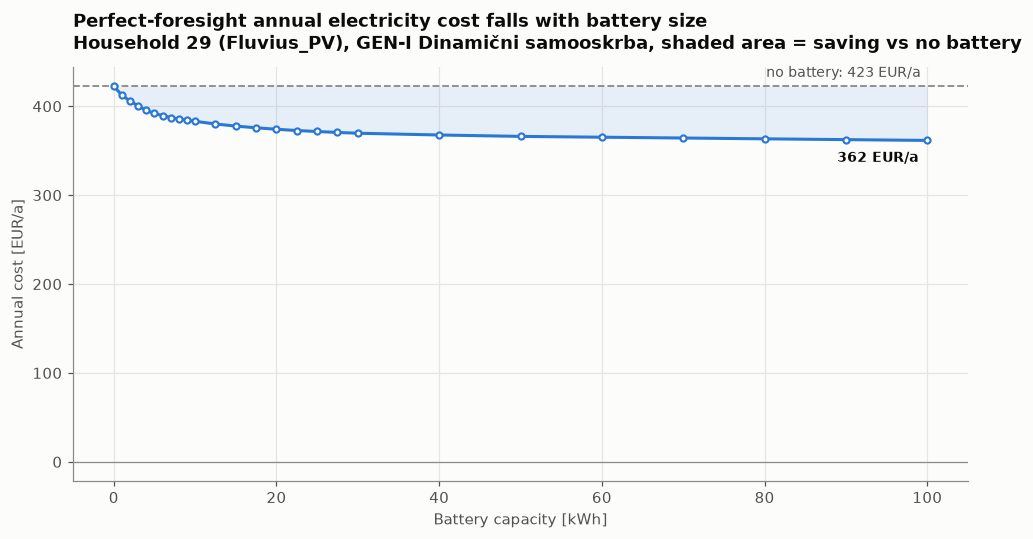

In [8]:
### Annual electricity cost vs battery size
fig, ax = plt.subplots(figsize=(9, 5))
cap = df_sizing["Capacity_kWh"]

ax.axhline(cost_no_battery, color=MUTED, lw=1.2, ls="--")
ax.annotate(f"no battery: {cost_no_battery:,.0f} EUR/a",
            xy=(cap.max(), cost_no_battery), xytext=(-4, 6),
            textcoords="offset points", ha="right", color=INK_2, fontsize=9)
ax.fill_between(cap, df_sizing["Cost_EUR"], cost_no_battery,
                color=SERIES[0], alpha=0.10, lw=0)
ax.plot(cap, df_sizing["Cost_EUR"], color=SERIES[0], lw=2,
        marker="o", ms=4, mfc=SURFACE, mew=1.4)
ax.axhline(0, color=MUTED, lw=0.8)

ax.annotate(f"{df_sizing['Cost_EUR'].iloc[-1]:,.0f} EUR/a",
            xy=(cap.iloc[-1], df_sizing["Cost_EUR"].iloc[-1]), xytext=(-6, -14),
            textcoords="offset points", ha="right", color=INK, fontsize=9,
            fontweight="semibold")

finish(ax, "Perfect-foresight annual electricity cost falls with battery size",
       "Battery capacity [kWh]", "Annual cost [EUR/a]",
       f"Household {HOUSEHOLD_ID} ({DATASET_NAME}), GEN-I Dinamični samooskrba, "
       f"shaded area = saving vs no battery")
plt.tight_layout()
plt.show()

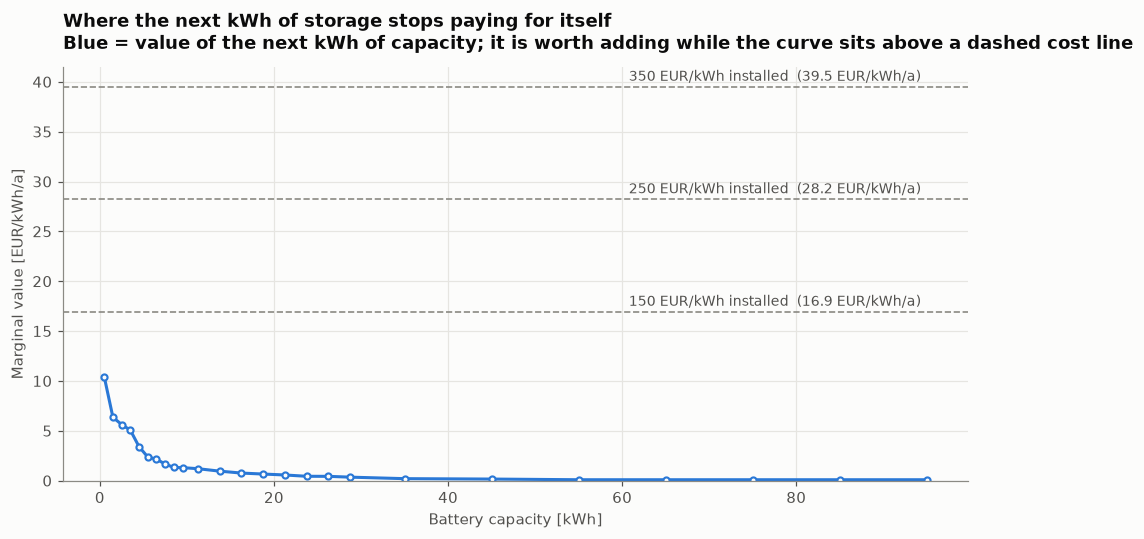

In [9]:
### Marginal value of capacity vs what capacity costs
fig, ax = plt.subplots(figsize=(9, 5))
mid = (df_sizing["Capacity_kWh"] + df_sizing["Capacity_kWh"].shift()) / 2

ax.plot(mid, df_sizing["Marginal_EUR_per_kWh"], color=SERIES[0], lw=2,
        marker="o", ms=4, mfc=SURFACE, mew=1.4)

for capex in CAPEX_SCENARIOS_EUR_PER_KWH:
    level = capex * annuity_factor
    ax.axhline(level, color=MUTED, lw=1.1, ls="--")
    ax.annotate(f"{capex:,.0f} EUR/kWh installed  ({level:,.1f} EUR/kWh/a)",
                xy=(mid.max(), level), xytext=(-4, 4), textcoords="offset points",
                ha="right", color=INK_2, fontsize=9)

ax.set_ylim(bottom=0)
finish(ax, "Where the next kWh of storage stops paying for itself",
       "Battery capacity [kWh]", "Marginal value [EUR/kWh/a]",
       "Blue = value of the next kWh of capacity; it is worth adding while the curve "
       "sits above a dashed cost line")
plt.tight_layout()
plt.show()

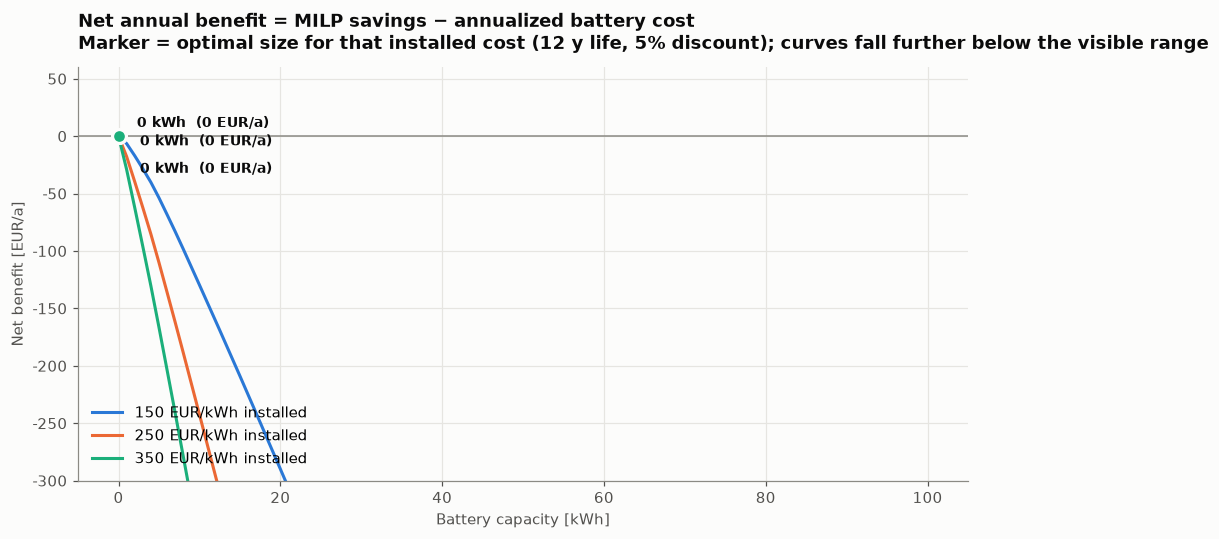

   150 EUR/kWh installed -> optimal   0.0 kWh, net     0.00 EUR/a
   250 EUR/kWh installed -> optimal   0.0 kWh, net     0.00 EUR/a
   350 EUR/kWh installed -> optimal   0.0 kWh, net     0.00 EUR/a


In [10]:
### Net annual benefit — the optimal size is the peak of each curve
fig, ax = plt.subplots(figsize=(9, 5))

optima = {}
label_offsets = [(12, 6), (14, -6), (14, -24)]
for capex, colour, offset in zip(CAPEX_SCENARIOS_EUR_PER_KWH, SERIES, label_offsets):
    net = df_sizing[f"Net_{int(capex)}"]
    ax.plot(cap, net, color=colour, lw=2, label=f"{capex:,.0f} EUR/kWh installed")
    best = int(net.idxmax())
    optima[capex] = (float(df_sizing["Capacity_kWh"][best]), float(net[best]))
    ax.plot([optima[capex][0]], [optima[capex][1]], marker="o", ms=9,
            color=colour, mfc=colour, mec=SURFACE, mew=2, zorder=3)
    ax.annotate(f"{optima[capex][0]:g} kWh  ({optima[capex][1]:,.0f} EUR/a)",
                xy=optima[capex], xytext=offset, textcoords="offset points",
                color=INK, fontsize=9, fontweight="semibold")

ax.axhline(0, color=MUTED, lw=1.0)
best_net = max(v for _, v in optima.values())
ax.set_ylim(-max(300.0, 3.5 * best_net), max(60.0, 1.6 * best_net))
finish(ax, "Net annual benefit = MILP savings − annualized battery cost",
       "Battery capacity [kWh]", "Net benefit [EUR/a]",
       f"Marker = optimal size for that installed cost "
       f"({BATTERY_LIFETIME_YEARS} y life, {DISCOUNT_RATE:.0%} discount); "
       f"curves fall further below the visible range")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

for capex, (size, net) in optima.items():
    print(f"{capex:6.0f} EUR/kWh installed -> optimal {size:5.1f} kWh, "
          f"net {net:8.2f} EUR/a")

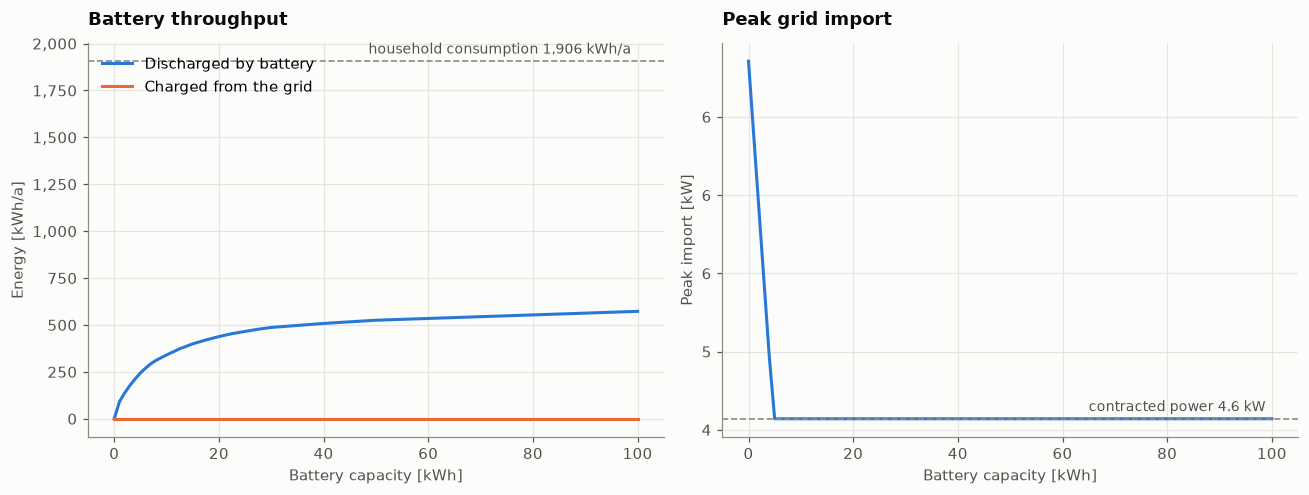

In [11]:
### Diagnostics: what the battery actually does as it grows
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
ax.plot(cap, df_sizing["Discharged_kWh"], color=SERIES[0], lw=2, label="Discharged by battery")
ax.plot(cap, df_sizing["Grid_Charged_kWh"], color=SERIES[1], lw=2, label="Charged from the grid")
ax.axhline(annual_consumption_kwh, color=MUTED, lw=1.1, ls="--")
ax.annotate(f"household consumption {annual_consumption_kwh:,.0f} kWh/a",
            xy=(cap.max(), annual_consumption_kwh), xytext=(-4, 5),
            textcoords="offset points", ha="right", color=INK_2, fontsize=9)
finish(ax, "Battery throughput", "Battery capacity [kWh]", "Energy [kWh/a]")
ax.legend(loc="upper left")

ax = axes[1]
ax.plot(cap, df_sizing["Peak_Import_kW"], color=SERIES[0], lw=2)
contracted = float(list(build_env(0.0).contracted_power_kw.values())[0])
ax.axhline(contracted, color=MUTED, lw=1.1, ls="--")
ax.annotate(f"contracted power {contracted:,.1f} kW",
            xy=(cap.max(), contracted), xytext=(-4, 5), textcoords="offset points",
            ha="right", color=INK_2, fontsize=9)
finish(ax, "Peak grid import", "Battery capacity [kWh]", "Peak import [kW]")

plt.tight_layout()
plt.show()

## 7. Read-out

In [12]:
best_capex = CAPEX_SCENARIOS_EUR_PER_KWH[-1]
lines = [
    f"Household {HOUSEHOLD_ID} ({DATASET_NAME}) — {annual_consumption_kwh:,.0f} kWh/a consumed, "
    f"{annual_generation_kwh:,.0f} kWh/a PV",
    f"Tariff: {PAKET_ID} ({PRICING_SCHEME}), regime {PRICING_REFERENCE_YEAR}",
    f"Continuous MILP, {len(BATTERY_SIZES_KWH)} capacities from "
    f"{BATTERY_SIZES_KWH.min():.0f} to {BATTERY_SIZES_KWH.max():.0f} kWh",
    "",
    f"Cost without a battery          : {cost_no_battery:10,.2f} EUR/a",
    f"Cost at {BATTERY_SIZES_KWH.max():.0f} kWh                 : "
    f"{float(df_sizing['Cost_EUR'].iloc[-1]):10,.2f} EUR/a",
    f"Largest achievable saving       : {max_savings:10,.2f} EUR/a",
    f"95 % of it reached at           : {knee_kwh:10,.1f} kWh",
    "",
    "Optimal size by installed battery cost:",
]
for capex, (size, net) in optima.items():
    lines.append(f"   {capex:6,.0f} EUR/kWh -> {size:5.1f} kWh   (net {net:+8,.2f} EUR/a)")
lines += [
    "",
    "Break-even installed cost (EUR/kWh) — a battery of that size pays for itself below this:",
]
for _, r in df_sizing[df_sizing["Capacity_kWh"] > 0].iterrows():
    if r["Capacity_kWh"] in (5.0, 10.0, 20.0, 50.0, 100.0):
        lines.append(f"   {r['Capacity_kWh']:5.1f} kWh -> {r['Break_Even_Capex']:7,.0f} EUR/kWh"
                     f"   (simple payback at {REFERENCE_CAPEX:,.0f} EUR/kWh: "
                     f"{r['Payback_y']:5.1f} y)")

print("\n".join(lines))

Household 29 (Fluvius_PV) — 1,906 kWh/a consumed, 1,268 kWh/a PV
Tariff: GENI_SAMO_REDNI (si_samooskrba), regime 2026
Continuous MILP, 26 capacities from 0 to 100 kWh

Cost without a battery          :     422.75 EUR/a
Cost at 100 kWh                 :     361.55 EUR/a
Largest achievable saving       :      61.20 EUR/a
95 % of it reached at           :       70.0 kWh

Optimal size by installed battery cost:
      150 EUR/kWh ->   0.0 kWh   (net    +0.00 EUR/a)
      250 EUR/kWh ->   0.0 kWh   (net    +0.00 EUR/a)
      350 EUR/kWh ->   0.0 kWh   (net    +0.00 EUR/a)

Break-even installed cost (EUR/kWh) — a battery of that size pays for itself below this:
     5.0 kWh ->      55 EUR/kWh   (simple payback at 250 EUR/kWh:  40.5 y)
    10.0 kWh ->      35 EUR/kWh   (simple payback at 250 EUR/kWh:  63.0 y)
    20.0 kWh ->      22 EUR/kWh   (simple payback at 250 EUR/kWh: 102.8 y)
    50.0 kWh ->      10 EUR/kWh   (simple payback at 250 EUR/kWh: 220.6 y)
   100.0 kWh ->       5 EUR/kWh   (si

### Caveats worth keeping in view

* **Perfect foresight.** Every point is an upper bound; a real controller (DQN, MPC) captures
  only part of it, so the true optimal size is at or below what these curves show.
* **0.1 % MIP gap.** Each point is within 0.1 % of its true optimum, not exactly on it. That
  is ~0.4 EUR on this bill, against ~20 EUR between neighbouring capacities. Set
  `SOLVER_GAP_REL = 0` for proven optima at roughly 10-20x the runtime.
* **Arbitrage through the grid.** The tariff model credits every exported kWh at
  SIPX − 0.01199 EUR/kWh regardless of where it came from, so the MILP is free to buy cheap
  grid energy and sell it back later. The *Battery throughput* panel makes this visible: where
  "charged from the grid" is a large share of throughput, the savings are trading revenue
  rather than PV self-consumption, and they depend on the 2024 SIPX spread repeating.
* **Peak charges.** `peak_reset_months=None` (the repository default) ratchets one peak across
  the whole year and charges the excess once. The real SI regulation settles excess power per
  calendar month; setting `PEAK_RESET_MONTHS = 1` switches to that and makes peak shaving a
  larger share of the battery's value.
* **One year, one household.** 2024 SMP volatility drives most of the value here; re-run with
  another `HOUSEHOLD_ID` / price year before generalizing.